# Training

In this script, we train (or actually, finetune) a large language model to predict party affiliation from the speeches.

In [ ]:
!pip install evaluate

In [ ]:
!pip install datasets transformers[sentencepiece]
!pip install accelerate

In [2]:
import os
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from datasets import Dataset, DatasetDict, load_dataset
from evaluate import load as load_metric
from sklearn.metrics import (
accuracy_score,
classification_report,
confusion_matrix,
ConfusionMatrixDisplay,
f1_score,
)
from transformers import (
AutoModelForSequenceClassification,
AutoTokenizer,
DataCollatorWithPadding,
get_scheduler,
)
from accelerate import Accelerator

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path_to_data = '/content/drive/MyDrive/TL/data/'
path_to_model = '/content/drive/MyDrive/TL/models/'

In [5]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


## Load data for training

Here, we load the data. We allow the user to of the script to decide whether they want to use the data with or without party names; here we opt for the data without party names.

In [15]:
with_party_info = ['no', 'yes'][0]
with_party_info

'no'

In [16]:
if with_party_info == 'yes':
  train_df = pd.read_parquet(path_to_data + 'speeches_party_train.parquet')
  val_df = pd.read_parquet(path_to_data + 'speeches_party_val.parquet')
  test_df = pd.read_parquet(path_to_data + 'speeches_party_test.parquet')
  model_name = 'GottBERT_party'
else:
  train_df = pd.read_parquet(path_to_data + 'speeches_noparty_train.parquet')
  val_df = pd.read_parquet(path_to_data + 'speeches_noparty_val.parquet')
  test_df = pd.read_parquet(path_to_data + 'speeches_noparty_test.parquet')
  model_name =  'GottBERT_noparty'

In [8]:
train_df.head()

,legislative_period,date,speaker_id,first_name,last_name,role,party,labels,no_words,speech,no_words_stripped,no_chars
0,19,07.05.2020,11003790,Jan,Korte,keine,Die Linke,3,410,Vielleicht hat es was mit Ihren Auftritten und...,566,2649
1,19,07.09.2021,11003584,Gesine,Lötzsch,keine,Die Linke,3,421,Ein Virus kann doch nicht mit militärischer Lo...,813,2923
2,20,07.07.2022,11003848,Petra,Sitte,keine,Die Linke,3,352,"Nun zur Sache. Es ist einerseits erschreckend,...",363,2580
4,19,12.02.2021,11004276,Thorsten,Frei,keine,CDU/CSU,0,263,Es ist in der Tat so: Als wir uns vor knapp ei...,263,1733
5,20,21.11.2022,11005069,Ingeborg,Gräßle,keine,CDU/CSU,0,444,Die Finanzlage muss Sie doch mindestens genaus...,827,2977


We transform the data frames into data sets so they can be used for training:

In [17]:
ds_training = Dataset.from_pandas(train_df[['speech', 'labels']])
ds_val = Dataset.from_pandas(val_df[['speech', 'labels']])
ds_test = Dataset.from_pandas(test_df[['speech', 'labels']])

dataset = DatasetDict({
    'train': ds_training,
    'validation': ds_val,
    'test': ds_test
    })

## Import the model and perform tokenization

In [18]:
checkpoint = 'TUM/GottBERT_base_best'
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Define a function which tokenizes the data sets:

In [19]:
def tokenize_function(example):
  return tokenizer(example['speech'],truncation=True, padding = "max_length", max_length = 512)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/37797 [00:00<?, ? examples/s]

Map:   0%|          | 0/14717 [00:00<?, ? examples/s]

Map:   0%|          | 0/12568 [00:00<?, ? examples/s]

In [20]:
# remove irrelevant columns:
tokenized_dataset = tokenized_dataset.remove_columns(['speech', '__index_level_0__'])

# set the format of the datasets so they return PyTorch tensors instead of lists
tokenized_dataset.set_format("torch")

# load the data into the data loader:
train_dataloader = DataLoader(
    tokenized_dataset["train"], shuffle=True, batch_size= 40, collate_fn=data_collator
)
eval_dataloader = DataLoader(
    tokenized_dataset["validation"], batch_size= 40, collate_fn=data_collator
)
test_dataloader = DataLoader(
    tokenized_dataset["test"], batch_size= 40, collate_fn=data_collator
)

In [21]:
# Free RAM:
import gc
del train_df
del val_df
del test_df
del ds_val
del ds_training
del ds_test
del dataset

gc.collect()

118

In [14]:
# Check formatting:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([40]),
 'input_ids': torch.Size([40, 512]),
 'attention_mask': torch.Size([40, 512])}

## Load and train model

In [15]:
path_to_model = '/content/drive/MyDrive/TL/models/'

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=6)

model.safetensors:   0%|          | 0.00/504M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at TUM/GottBERT_base_best and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
optimizer = AdamW(model.parameters(), lr= 5e-5)

num_epochs = 3
num_training_steps = num_epochs * len(train_dataloader)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

print(num_training_steps)


2835


In [18]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
print(device)

cuda


In [19]:
progress_bar = tqdm(range(num_training_steps))

model.train()
for epoch in range(num_epochs):
    for batch in train_dataloader:
       # send the data to the GPU:
       batch = {k: v.to(device) for k, v in batch.items()}
       # compute model-outputs
       outputs = model(**batch)
       # compute loss
       loss = outputs.loss
       # compute gradients with loss
       loss.backward()
       # make a training step
       optimizer.step()
       # update learning rate
       lr_scheduler.step()
       # zero the gradients
       optimizer.zero_grad()
       progress_bar.update(1)

# Save the trained model:
torch.save(model.state_dict(), path_to_model + model_name + ".pth")

  0%|          | 0/2835 [00:00<?, ?it/s]

In [7]:
# This is how the model can be loaded:
checkpoint = 'TUM/GottBERT_base_best'
model_name = 'GottBERT_noparty'
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=6)
model.load_state_dict(torch.load(path_to_model + model_name + ".pth", map_location=torch.device('cpu')))

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at TUM/GottBERT_base_best and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<All keys matched successfully>

In [23]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

## Evaluation for the validation set

Here, we compute performance metrics for the validation set. We could use this to compare different models and then decide for a final model. Since we have only tested a single model, this step is not strictly necessary.

In [12]:
with open(path_to_data +'speeches_mapping.pkl', 'rb') as f:
    parties = pickle.load(f)
party_labels = [str(k) for k in parties]


Compute performance metrics for the validation set:

In [24]:
all_predictions = []
all_labels = []

metric = load_metric('glue', 'mrpc')
model.eval()

for batch in eval_dataloader:
  batch = {k: v.to(device) for k, v in batch.items()}
  with torch.no_grad():
    outputs = model(**batch)

  logits = outputs.logits
  predictions = torch.argmax(logits, dim=-1)
  metric.add_batch(predictions = predictions, references = batch["labels"])

  all_predictions.extend(predictions.cpu().numpy())
  all_labels.extend(batch["labels"].cpu().numpy())

print("Accuracy:",accuracy_score(all_labels, all_predictions))
print("f1-score:", f1_score(all_labels, all_predictions, average = "weighted"))

report = classification_report(all_labels, all_predictions)
print("\nClassification Report:")
print(report)

Accuracy: 0.6951824420737922
f1-score: 0.6965675132213066

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.79      0.65      2173
           1       0.55      0.67      0.60      2670
           2       0.70      0.55      0.61      2622
           3       0.89      0.78      0.83      2409
           4       0.69      0.53      0.60      2539
           5       0.91      0.89      0.90      2304

    accuracy                           0.70     14717
   macro avg       0.72      0.70      0.70     14717
weighted avg       0.71      0.70      0.70     14717



Make confusion matrix:

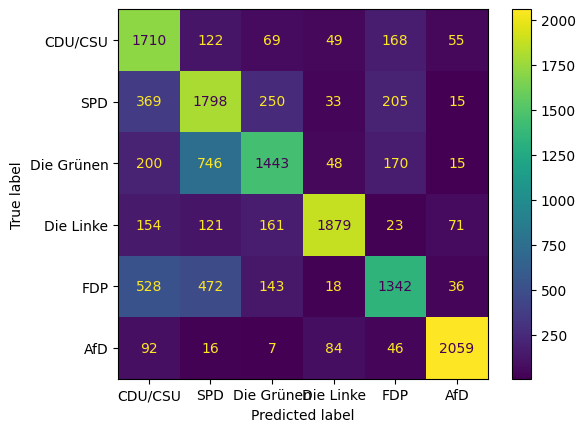

In [25]:
cm = confusion_matrix(all_labels, all_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = party_labels)
disp.plot()
plt.show()